# Attention is all you need instead of love exploration☠️

## What is attention mechanism?

To answer this question, let's start with some back story.

Back in 2014 when researchers are working on an text translation model which require contextual understanding and grammar alignment.

They invented `encoder-decoder` model, in which `encoder` reads and processes the text, whereas `decoder` translates text.

Translations before `transformer` use `RNN(Recurrent Neural Network)` for the most popular encoder-decoder language translation model, which basically means output from the previous step is fed to current text to **update a hidden state** at each step with the upcoming new word. The model will use the final hidden state to generate translate sentence **one word at a time**

There is certainly a problem here, you may have also spotted: Since RNN cannot directly access previous hidden state from the encoder during the training phase, **it relies only on current hidden state**. Therefore this leads to a **loss of context**, especially in complex sentences where dependencies might span long distances, like:

- *The **cat** that was sitting on the mat, which was next to the dog, **jumped.***

Attention come to resolve this problem!

### Attention here means
<div class='alert alert-block alert-info'>
The mechanism's ability to compute attention weights by relating different positions in a single input sequence.
</div>

## 1. Simplified Attention Mechanism


Let's start by implementing a compact self attention python class, then to clarify every single component in this class.

In [1]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

- Each row represents a word.
- Each column represents an embedding dimension.

Let's start with a compact **self-attention** python class.

In [ ]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))
        # Initiating random Q,K,V matrices, which are going to be optimized

    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value
        # Resulting matrices = inputs * corresponding matrices

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )

        context_vec = attn_weights @ values
        return context_vec


In this PyTorch code, **SelfAttention_v1** is a class derived from **nn.Module**, which is a
**fundamental building block** of PyTorch models, which provides necessary functionalities for
model layer creation and management.


The `__init__` method initializes trainable weight matrices `W_query`, `W_key`, and `W_value` for queries, keys, and values, each **transforming** the input dimension d_in to an
output dimension d_out.


During the forward pass, using the forward method, we compute the **attention scores**
(`attn_scores`) by multiplying queries and keys transposed, **normalizing** these scores using softmax.

    
Finally, we create a **context vector** by weighting the values with these normalized attention
scores.


In [ ]:
torch.manual_seed(123)
x_2 = inputs[1]
d_in = inputs.shape[1]
d_out = 2
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


Since inputs contains six embedding vectors, we get a matrix storing the six
**context vectors**, as shown in the above result. 


We can improve the `SelfAttention_v1` implementation further by utilizing PyTorch's
`nn.Linear` layers, which effectively perform matrix multiplication when the bias units are
disabled. 


Additionally, a significant advantage of using `nn.Linear` instead of manually
implementing `nn.Parameter(torch.rand(...))` is that nn.Linear has an **optimized** weight
initialization scheme, contributing to more stable and effective model training.



In [ ]:
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        # We project the input into three different representations: keys, queries, and values. 

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values
        return context_vec


In [9]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


Note that `SelfAttention_v1` and `SelfAttention_v2` give different output trends because they
use **different initial weights** for the weight matrices since ``nn.Linear`` uses a more
sophisticated weight initialization scheme.

### **Clarifications**

#### What is Query, Keys and Values?

- **Query** represents the current token that the model focuses on.
- **Key** are used to match with the query.
- **Value** represents the actual content or representation of the input items. Once the model determines which keys(which parts of the input) are most relavent to the query(current focus item), it retrives the corresponding values.

---

- **Imagine a library**:  
  - A **query** is the question you ask the librarian.  
  - A **key** is the index entry for each book.  
  - A **value** is the actual content inside each book.  
  You compare your question (query) to the index entries (keys) to decide which books (values) to read and how much attention to give each. 



#### What is projection here mean?

In ethis case, we initialted random `nn.Linear` layers for Q, K, and V, so when we use `keys = self.W_key(x)`, x is basically going through `y = x*W + b`, in which `x` is input vector, `W` is weight, while `b` is bias. 

#### Why `-1`?

- `keys.shape[-1]` means the last dimension, which is the dimension of vector.
- `dim=-1` means perfoming softmax at the last dimension.

So when we implement multihead attention later where the dimension could change, this piece of code is still usable.

#### Why `sqrt(dimension)`?

- `softmax()` is sensitive to magnitudes of its inputs. When the inputs are large, the differences between the exponential values of each input become much more pronounced, causing the `softmax` output to become 'peaky', where the highest value receives almost all the probability mass, and the rest receives very little. Model will therefore be confident in one particular `key`

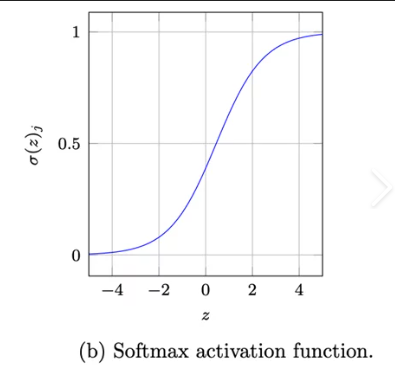

- The dot product of Q and K increases the variance beacuse mulpliplying 2 random numbers increases the variance. The increase in variance grows with dimension. dividing by `sqrt(dimension)` keeps the variance close to 1.

## 2. Causal Attention

### *We know that...* 

LLMs use all of their previous tokens to predict the next token, WITHOUT knowing what the future tokens are.

<div class='alert alert-block alert-success'>
Causal attention restricts the model to only consider previous and current inputs in a sequence when processing any given token.
</div>

### Intuition
Use the mask (a lower triangle filled with 1) to multiply by the original attention weights, then normalize using softmax again to get the masked attention weights.

Assume we already got our attention weights.

In [ ]:
attn_weights = torch.tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
                            [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
                            [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
                            [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
                            [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
                            [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],)
context_length = attn_weights.shape[0]

In [15]:
mask = torch.tril(torch.ones(context_length, context_length))
print(mask)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [17]:
masked = attn_weights * mask

There are actually two ways to normaize this!
#### 1. Probability intuition

In [18]:
row_sums = masked.sum(dim=1, keepdim=True)
masked_norm = masked / row_sums
print(masked_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5516, 0.4484, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3801, 0.3097, 0.3102, 0.0000, 0.0000, 0.0000],
        [0.2759, 0.2461, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1985, 0.1887, 0.1970, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]])


#### 2. Mathematical
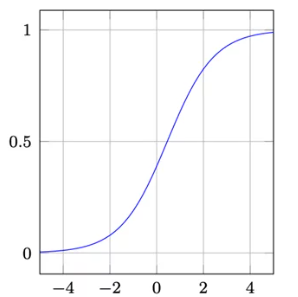

According to the shape of Softmax, -inf for the x coordinate is treated as 0 for the y coordinate.

This time, we assume we already get attention scores.

In [ ]:
attn_scores = torch.tensor([[ 0.2899,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
                            [ 0.4656,  0.1723,  0.1751,  0.0259,  0.1771,  0.0085],
                            [ 0.4594,  0.1703,  0.1731,  0.0259,  0.1745,  0.0090],
                            [ 0.2642,  0.1024,  0.1036,  0.0186,  0.0973,  0.0122],
                            [ 0.2183,  0.0874,  0.0882,  0.0177,  0.0786,  0.0144],
                            [ 0.3408,  0.1270,  0.1290,  0.0198,  0.1290,  0.0078]])

In [ ]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
# Create tensor that the upper triangle is 1
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
#Replace 1 with -inf
print(masked)


tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]])


Apply Softmax here, and we are done grabbing attention weights.

In [ ]:
keys = sa_v2.W_key(inputs)
# Linear projection
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=-1)
# Vanilla softmax usage
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2759, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1887, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]])


<div class="alert alert-block alert-warning">

Masking in Transformers sets scores for future tokens to a large negative value, making their influence in the softmax calculation effectively zero. 

The softmax function then recalculates attention weights only among the unmasked tokens. 

This process ensures no information leakage from masked tokens, focusing the model solely on the intended data.

</div>

## 2.1 Tweak! Dropout

<div class='alert alert-block alert-success'>
Dropout is a deep learning texhnique where randomly selected hidden layer units are ignored during training.
</div>

### But why?
In fact, in the training process there are many 'lazy neurons' that don't contribute to any of the parameter update, causing a waste of computational power.

In [26]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5) # Dropout rate is 0.5
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6207, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]])


Note that the remaining elements should be multiplied by `1/rate`

---

Let's put it all together and create a class:

In [27]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape) 

torch.Size([2, 6, 3])


<div class="alert alert-block alert-info">

This results in a 3D tensor consisting of 2 input texts with 6 tokens each, where each token
is a 3-dimensional embedding vector.
    
</div>

OK, let's code!

In [30]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1,2)
        attn_scores.masked_fill(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )
        attn_weights = torch.softmax(attn_scores/keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ values
        return context_vec



<div class="alert alert-block alert-warning">

The use of register_buffer in
PyTorch is not strictly necessary for all use cases but offers several advantages here. 

For
instance, when we use the CausalAttention class in our LLM, buffers are automatically
moved to the appropriate device (CPU or GPU) along with our model, which will be relevant
when training the LLM.

This means we don't need to manually ensure
these tensors are on the same device as your model parameters, avoiding device mismatch
errors.

</div>

In [32]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape)
print(context_vecs)

context_vecs.shape: torch.Size([2, 6, 2])
tensor([[[-0.5337, -0.1051],
         [-0.5323, -0.1080],
         [-0.5323, -0.1079],
         [-0.5297, -0.1076],
         [-0.5311, -0.1066],
         [-0.5299, -0.1081]],

        [[-0.5337, -0.1051],
         [-0.5323, -0.1080],
         [-0.5323, -0.1079],
         [-0.5297, -0.1076],
         [-0.5311, -0.1066],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)


<div class="alert alert-block alert-info">

As we can see, the resulting context vector is a 3D tensor where each token is now represented by a 2D
embedding.
    
</div>

Note the dimension change here means *3 batches turning into 2 batches*